# Práctica #2 - Parte 1


### Resumen 
asopqsjj

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from statistics import mean
import scipy.io

#### Implementación de funciones
- Se crea una función rms, donde en el argumento se ingresa la señal de la cual se pretende obtener el valor.

In [20]:
y= 3*np.sin(2*np.pi*1*np.linspace(0, 1, 1000)) + 0.5*np.random.randn(1000)

# RMS de cada señal
def rms(signal):
    return np.sqrt(np.mean(signal**2))

RMS1 = rms(y)

print("RMS Voluntario 1:", RMS1)

RMS Voluntario 1: 2.195557601382914


- ahora se seleccione un ciclo cardiaco de la señal y se grafica. Luego calculamos el promedio, el valor RMS, la varianza y la desviación estándar del ciclo.

In [8]:
import numpy as np

promedio = np.mean(ciclos, axis=0)
varianza = np.var(ciclos, axis=0)
desviacion = np.std(ciclos, axis=0)

for i in range(len(promedio)):
    print(f"Ciclo {i+1}:")
    print(f"Promedio = {promedio[i]:.4f}")
    print(f"Varianza = {varianza[i]:.4f}")
    print(f"Desviacion estandar = {desviacion[i]:.4f}")


NameError: name 'ciclos' is not defined

In [17]:
datos = scipy.io.loadmat("signals.mat")
print(datos)
# 1. Extraer y forzar a que sean vectores de 1 dimensión (1D)
senal_original = np.squeeze(datos["ECG_asRecording"]) # Verifica que la llave sea la correcta
senal_filtrada = np.squeeze(datos["ECG_filtered"])

# 2. Obtener la cantidad exacta de puntos
N_original = len(senal_original)
N_filtrada = len(senal_filtrada)
Fs = 1024
# 3. Crear los vectores de tiempo 
t = np.arange(N_original) / Fs
t_filtrada = np.arange(N_filtrada) / Fs

# (Opcional) Imprimir las dimensiones para confirmar que ahora son iguales
print(f"Dimensión de t: {t.shape} | Dimensión de señal original: {senal_original.shape}")
print(f"Dimensión de t_filtrada: {t_filtrada.shape} | Dimensión de señal filtrada: {senal_filtrada.shape}")
print(f"La señal filtrada dura {N_filtrada} segundos")
print(f"La señal original dura {N_original} segundos")


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015', '__version__': '1.0', '__globals__': [], 'Fs': array([[1024]], dtype=uint16), 'ECG_asRecording': array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]], shape=(1, 30720)), 'ECG_filtered': array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]],
      shape=(1, 30720)), 'EMG_filtered1': array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]], shape=(1, 30721)), 'EMG_filtered2': array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]], shape=(1, 30721)), 'EMG_asRecording1': array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]], shape=(1, 30721)), 'EMG_asRecording2': array([[-3109.97558594, -3231.01391602, -3302

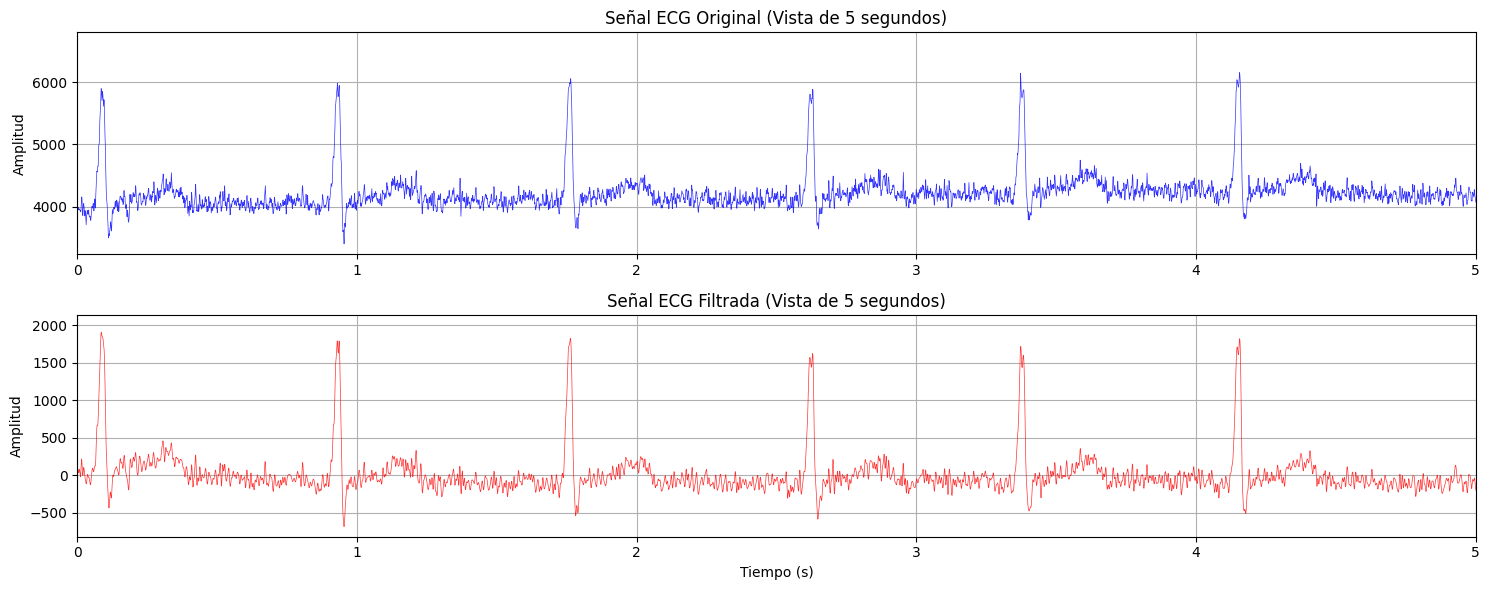

In [19]:
# Aumentar el ancho de la figura a 15 pulgadas
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
# Añadir linewidth más delgado y alpha para transparencia
plt.plot(t, senal_original, color='blue', linewidth=0.5, alpha=0.8)
plt.title("Señal ECG Original (Vista de 5 segundos)")
plt.ylabel("Amplitud")
# Limitar el eje X para ver solo los primeros 5 segundos
plt.xlim(0, 5) 
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_filtrada, senal_filtrada, color='red', linewidth=0.5, alpha=0.8)
plt.title("Señal ECG Filtrada (Vista de 5 segundos)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
# Limitar el eje X al mismo rango para poder compararlas directamente
plt.xlim(0, 5) 
plt.grid(True)

plt.tight_layout()
plt.show()

Métricas del Ciclo Cardíaco (Señal Original):
Promedio (Offset DC): 4198.21
Valor RMS: 4208.69
Varianza: 88096.03
Desviación Estándar: 296.81


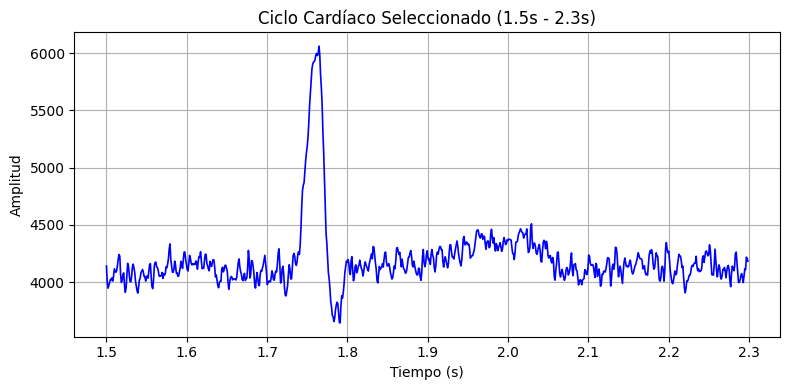

In [ ]:

t_inicio = 1.5
t_fin = 2.3
Fs = 1024

idx_inicio = int(t_inicio * Fs)
idx_fin = int(t_fin * Fs)

ciclo_cardiaco = senal_original[idx_inicio:idx_fin]
t_ciclo = t[idx_inicio:idx_fin]

promedio = np.mean(ciclo_cardiaco)
valor_rms=rms(ciclo_cardiaco)
varianza = np.var(ciclo_cardiaco)
desviacion_std = np.std(ciclo_cardiaco)

print("Métricas del Ciclo Cardíaco (Señal Original):")
print(f"Promedio (Offset DC): {promedio:.2f}")
print(f"Valor RMS: {valor_rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo_cardiaco, color='blue', linewidth=1.2)
plt.title("Ciclo Cardíaco Seleccionado (1.5s - 2.3s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

Métricas del Ciclo Cardíaco (Señal Original):
Promedio (Offset DC): -5.99
Valor RMS: 294.62
Varianza: 86764.69
Desviación Estándar: 294.56


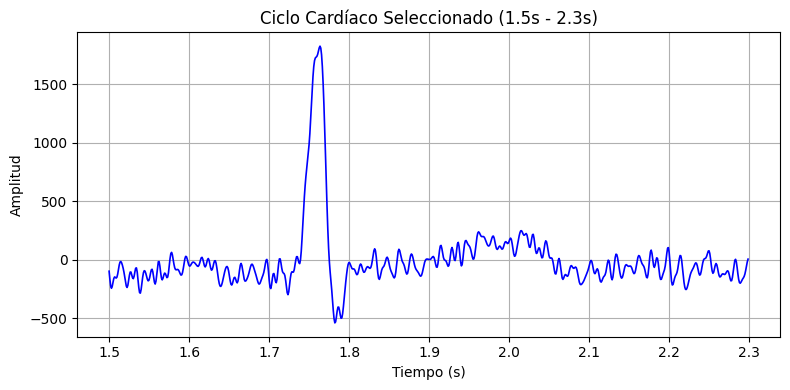

In [ ]:
t_inicio = 1.5
t_fin = 2.3
Fs = 1024

idx_inicio = int(t_inicio * Fs)
idx_fin = int(t_fin * Fs)

ciclo_cardiaco = senal_filtrada[idx_inicio:idx_fin]
t_ciclo = t[idx_inicio:idx_fin]

promedio = np.mean(ciclo_cardiaco)
valor_rms=rms(ciclo_cardiaco)
varianza = np.var(ciclo_cardiaco)
desviacion_std = np.std(ciclo_cardiaco)

print("Métricas del Ciclo Cardíaco (Señal Original):")
print(f"Promedio (Offset DC): {promedio:.2f}")
print(f"Valor RMS: {valor_rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo_cardiaco, color='blue', linewidth=1.2)
plt.title("Ciclo Cardíaco Seleccionado (1.5s - 2.3s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()